In [1]:
%matplotlib inline

In [64]:
import pandas as pd
import numpy as np
from scipy import stats
#from scipy.stats import entropy
#from scipy.stats import ttest_ind, chi2_contingency
import matplotlib.pyplot as plt
#import diptest
import os


# Bias Under Pressure: A Structural Analysis of Referee Bias in NBA Close Games

## 1. Abstract

This study examines whether referee errors in NBA close games follow a systematic pattern consistent with known cognitive biases — specifically home court bias driven by crowd pressure, strength bias toward the stronger team, and star player bias toward higher-rated players. The analysis draws on NBA Last Two Minute (L2M) reports covering seasons 2015–2025 [AtlhawksfanaticL2M] as the primary dataset, and pre-game ELO ratings [NeilPaineELO] as an independent second source. The methodology of Pelechrinis (2023) [PelechrinisL2M] is replicated and extended to the Post-COVID period (2023–2025). The COVID-19 pandemic, during which NBA games were played without fans, serves as a natural comparison period within the dataset.

## 2. Introduction  
Prior work has documented several types of referee bias in professional sports. Home court bias is perhaps the most studied — referees tend to favor the home team, and this effect has been linked to crowd noise and social pressure [PelechrinisL2M]. Bias toward stronger and more successful teams has also been reported in football [ErikstadJohansen2020], while evidence for star player bias in the NBA suggests that higher-salaried players draw more favourable calls [Barrett2021].

In this project, I examine whether NBA referee errors in close games show systematic patterns across three dimensions: home court advantage, team strength as measured by pre-game ELO ratings, and individual player quality as measured by Player Efficiency Rating (PER). The analysis uses Last Two Minute reports (2015–2025) [AtlhawksfanaticL2M], which provide ground truth — every referee decision in the final two minutes of close games is graded as correct or incorrect by the NBA league office. The COVID-19 pandemic, during which games were played without fans, serves as a natural comparison period within the dataset.

## 3. Methods

### 3.1 Core Definitions

Following Pelechrinis (2023) [PelechrinisL2M], referee errors are classified by their directional benefit. For each game, incorrect calls (IC) and incorrect non-calls (INC) are classified by which side benefits from the error.

The **whistle benefit** $\beta$ — the number of errors that favor the home team:
$$\beta = |INC : committing\_side = home| + |IC : committing\_side = away|$$

The **whistle detriment** $\delta$ — the number of errors that favor the away team:
$$\delta = |INC : committing\_side = away| + |IC : committing\_side = home|$$

The **Net Whistle Gain** (NWG) for the home team:
$$NWG = \beta - \delta$$

A positive NWG indicates that the home team benefited more from referee errors than expected. This measure is extended with the **Asymmetry Ratio** (AR), which normalizes NWG to a [0,1] scale for cross-group comparison:
$$AR = \frac{\beta}{\beta + \delta}$$

An AR of 0.5 indicates no directional bias. AR > 0.5 indicates bias favoring the home team; AR < 0.5 indicates bias favoring the away team.

### 3.2 Monte Carlo Simulation

To assess statistical significance of NWG, the simulation approach of Pelechrinis (2023) [PelechrinisL2M] is followed. A chi-square test on $\beta$ and $\delta$ would ignore the fact that different violation types have different base rates of being called correctly. To control for this, the expected distribution of NWG is simulated under the null hypothesis of no bias.

For each violation type $v$, two probabilities are estimated from the observed data:
$$p_1^v = \frac{|INC_v|}{|INC_v| + |IC_v| + |CC_v|}$$
$$p_2^v = \frac{|INC_v| + |IC_v|}{|INC_v| + |IC_v| + |CC_v|}$$

For each simulation run, every event in the dataset is assigned a random number $r \sim U(0,1)$. The decision boundaries are:
$$\text{decision} = \begin{cases} IC & \text{if } r < p_1^v \\ INC & \text{if } p_1^v \leq r < p_2^v \\ CC & \text{if } r \geq p_2^v \end{cases}$$

The simulated NWG ($\widehat{NWG}$) is computed for each run. After $n = 10{,}000$ simulations, the empirical p-value is:
$$p = \frac{|\{\widehat{NWG} \geq NWG_{real}\}|}{n}$$

The effect size is reported as:
$$\text{effect} = NWG_{real} - \mathbb{E}[\widehat{NWG}]$$

### 3.3 Research Questions and Hypotheses

**RQ1: Home Court Bias Across Periods**

Home court bias is tested across three periods defined by crowd presence conditions:
- Pre-COVID: seasons 2015–2019
- COVID: seasons 2020–2022
- Post-COVID: seasons 2023–2025

$$H_0^{RQ1}: \text{effect} = 0 \quad \text{(no systematic home bias)}$$
$$H_1^{RQ1}: \text{effect} > 0 \quad \text{(errors favor home team)}$$

Statistical test: Monte Carlo simulation (Section 3.2).
Significance level: $\alpha = 0.05$.

**RQ2: Strength Bias**

Referee errors are tested for systematic bias toward the stronger team, 
defined by pre-game ELO rating difference:
$$elo\_diff = ELO_{home} - ELO_{away}$$

AR is compared between two groups: games where the home team is stronger 
($elo\_diff > 0$) and games where the home team is weaker ($elo\_diff < 0$). 
Additionally, the in-game score difference is examined as a moderating factor:
$$score\_diff = score_{home} - score_{away}$$

$$H_0^{RQ2}: AR_{strong} = AR_{weak} \quad \text{(no strength bias)}$$

Statistical tests: Chi-square test on aggregated $\beta$ and $\delta$ per group; 
two-sample T-test on AR distributions.

**RQ3: Star Player Bias**

Errors are tested for systematic bias toward players with higher career Player Efficiency Rating (PER), used as a proxy for player status and reputation. Players are grouped into terciles by PER:

- Low PER: bottom third
- Medium PER: middle third
- High PER: top third

$$H_0^{RQ3}: AR_{high} = AR_{medium} = AR_{low} \quad \text{(no player bias)}$$

Statistical tests: Chi-square test per group; one-way ANOVA on AR across groups.

### 3.4 Structural Comparison: Kolmogorov-Smirnov Test

The two-sample Kolmogorov-Smirnov test is applied to compare AR distributions across groups. The KS statistic is:

$$D = \sup_x |F_1(x) - F_2(x)|$$

where $F_1$ and $F_2$ are the empirical cumulative distribution functions of two AR distributions. A small $D$ with a large p-value indicates that the two distributions are statistically indistinguishable.

$$H_0^{KS}: F_1 = F_2 \quad \text{(distributions are identical)}$$
$$H_1^{KS}: F_1 \neq F_2 \quad \text{(distributions differ)}$$

KS tests are applied across periods:
- Pre-COVID vs COVID
- Pre-COVID vs Post-COVID
- COVID vs Post-COVID

Additionally, KS tests are applied across the three bias types to examine whether they share a common distributional structure:
- AR of home bias vs AR of strength bias
- AR of home bias vs AR of star player bias
- AR of strength bias vs AR of star player bias

$$H_0^{KS}: F_{home} = F_{strength} = F_{star}$$

Multiple hypothesis tests are conducted at $\alpha = 0.05$, which increases the risk of false positive results. Some researchers recommend **Bonferroni correction** to address this, but the unadjusted approach of Pelechrinis (2023) [PelechrinisL2M] is followed here. Results should be interpreted with this limitation in mind.

### 3.6 Assumptions

The following assumptions underlie the analysis:

1. L2M grades are treated as ground truth. The NBA league office grading is accepted as correct — no independent verification of individual decisions is performed.

2. Errors are independent across plays within a game. The Monte Carlo simulation treats each play as an independent event, which may not hold if referees exhibit sequential bias (e.g., compensation strategies).

3. ELO ratings are a valid proxy for pre-game team strength. This assumes that the ELO system accurately captures relative team quality at the time of each game.

4. The three periods (Pre-COVID, COVID, Post-COVID) are treated as structurally distinct. This assumes that the COVID period represents a genuine discontinuity in crowd presence conditions, not a gradual transition.

5. CNC decisions are excluded as inconsistent across seasons, following Pelechrinis (2023) [PelechrinisL2M].

## 4. Data availibility

### 4.1. Initial Data Analysis (IDA)

#### 4.1.1 NBA Last Two Minute Reports

##### Dataset Overview

The primary dataset is the NBA Last Two Minute (L2M) reports, maintained by atlhawksfanatic [AtlhawksfanaticL2M]. A Last Two Minute Report, or “L2M,” is a play-by-play report regarding all calls and material non-calls in the last two minutes of the fourth quarter or the last two minutes of any overtime period (if applicable) for all games (including playoffs) that meet designated criteria. This dataset is selected for three reasons. First, it provides ground truth — every referee decision in the final two minutes of close games is independently graded as correct or incorrect by the NBA league office, which is rare in sports officiating research. Second, it is the same dataset used by Pelechrinis (2023) [PelechrinisL2M], allowing direct replication and comparison of results. Third, it covers seasons 2015–2025, which includes the COVID-19 period during which games were played without fans — a natural comparison condition for examining the role of crowd presence in referee decision-making.

The reports are released by the NBA for games that were within 5 points in the last two minutes. The dataset is compiled from two sources: archived PDF reports for earlier seasons and the official NBA API for more recent ones. It is supplemented with box score data from stats.nba.com, which adds referee identities, attendance, and player minutes [AtlhawksfanaticL2M]. The dataset is the primary source used in Pelechrinis (2023) [PelechrinisL2M], as confirmed by the accompanying code repository [PelechrinisCode].

In [3]:
nba_data = pd.read_csv('data/input/L2M_stats_nba.zip', low_memory=False)
# Shape
print('Shape:', nba_data.shape)

Shape: (90302, 53)


The dataset contains 90,302 rows and 64 columns. Each row represents a single graded play — either a call made by referees or a potential violation that was not called. It is fully described in the README of [AtlhawksfanaticL2M]. Based on the source documentation, the following columns are identified as candidates for analysis.

##### Data Quality

**Data types** — we inspect the type of each column to identify parsing issues. Dates stored as strings or booleans stored as objects will need conversion before analysis.

In [4]:
print(nba_data.head())
print(nba_data.dtypes)

  period     time         call_type decision  \
0     Q4  01:52.0    Foul: Shooting      CNC   
1     Q4  01:43.0    Foul: Shooting       CC   
2     Q4  01:32.0    Foul: Shooting       CC   
3     Q4  01:09.0  Foul: Loose Ball       CC   
4     Q4  00:53.0    Foul: Shooting      CNC   

                         game_details  page                    file  \
0  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
1  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
2  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
3  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
4  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   

      game_date  away_team home_team  ... committing_min committing_team  \
0  Mar 01, 2015  Cavaliers   Rockets  ...      30.950000             HOU   
1  Mar 01, 2015  Cavaliers   Rockets  ...      50.800000             CLE   
2  Mar 01, 2015  Cavaliers   Rockets  ...      42.233333

> Data Types - All columns are inspected for parsing issues. A full description of each column is available in the source documentation [AtlhawksfanaticL2M]. Key columns have the expected types: `playoff` is boolean, `season` and `ATTENDANCE` are numeric, and categorical columns (`decision`, `committing_side`, `disadvantaged_side`, `call_type`, `period`) are object as expected for string categories. Three columns require conversion before analysis: `date`, `game_date`, and `GameDate` are stored as object and require datetime conversion. `GAME_ID` is float64 but represents integer game IDs. All conversions will be performed in the Tidy Data Preparation section.

**Missing values** — we identify columns with missing data early. Some are expected — for example, `committing_min` is missing where the NBA made input errors. Others may signal structural issues in the data.

In [5]:
# Missing values
print('\nMissing values:')
print(nba_data.isnull().sum()[nba_data.isnull().sum() > 0])


Missing values:
call_type                48
decision               2502
game_details          58270
page                  58270
call                     48
type                     48
networks              88993
game_id               32032
PCTime                32032
ImposibleIndicator    32032
Difficulty            34148
VideolLink            32032
Qualifier             90302
posID                 32032
posStart              32032
posEnd                32032
posTeamId             32032
teamIdInFavor         90302
errorInFavor          90302
imgChart              32032
GameId                32032
GameDate              32032
HomeTeamId            32032
AwayTeamId            32032
L2M_Comments          89809
GAME_ID                 631
ATTENDANCE             6509
committing_min         3183
committing_team        2433
committing_side        2433
disadvantaged_min     11681
disadvantaged_team     5801
disadvantaged_side     5801
type2                    48
dtype: int64


> Missing values are identified across all columns. They fall into three categories.  
> **Expected and structural:** `game_details` and `page` have 58,270 missing values each — absent for all API-sourced games. `networks`, `L2M_Comments`, `Qualifier`, `teamIdInFavor`, and `errorInFavor` are largely or entirely missing and are not used in the analysis. `GameId`, `GameDate`, `HomeTeamId`, `AwayTeamId`, `game_id`, `PCTime`, `posID`, `posStart`, `posEnd`, `posTeamId`, `imgChart`, and `VideolLink` have 32,032 missing values each — corresponding to PDF-sourced games.  
> **Require attention:** `decision` has 2,502 missing values representing plays not detectable without technology, excluded from analysis. `committing_side` and `disadvantaged_side` have 2,433 and 5,801 missing values respectively — critical for β and δ calculations, examined in Tidy. `GAME_ID` has 631 missing values. `ATTENDANCE` has 6,509 missing values affecting crowd pressure analysis.  
> **Known data quality issues:** `committing_min` has 3,183 missing values and `disadvantaged_min` has 11,681, partly due to NBA input errors [AtlhawksfanaticL2M]. `call_type`, `call`, `type`, and `type2` share 48 missing values — the same rows.
>
> Missing values in `decision` (2,502 blank entries) represent plays not detectable without technology and are excluded from analysis. The treatment of all missing values is detailed in the Tidy Data Preparation section.

**Duplicate Values** -we check whether the dataset contains any exact duplicate rows.

In [6]:
print('Duplicate rows:', nba_data.duplicated().sum())

Duplicate rows: 58


There are 58 duplicate lines. Inspect duplicate rows to identify their source and pattern

In [7]:
print(nba_data[nba_data.duplicated(keep=False)][
    ['season', 'home_team', 'away_team', 'date', 'decision', 'call_type', 'ATTENDANCE']
].sort_values('date').head(20))

      season  home_team      away_team        date decision  \
153     2015   Clippers  Trail Blazers  2015-03-04       CC   
154     2015   Clippers  Trail Blazers  2015-03-04       CC   
1892    2015  Cavaliers          Hawks  2015-05-24       CC   
1893    2015  Cavaliers          Hawks  2015-05-24       CC   
2023    2016      Hawks        Hornets  2015-10-30      NaN   
2024    2016      Hawks        Hornets  2015-10-30      NaN   
3392    2016      Bucks  Trail Blazers  2015-12-07      INC   
3393    2016      Bucks  Trail Blazers  2015-12-07      INC   
3414    2016       Heat        Wizards  2015-12-07       CC   
3415    2016       Heat        Wizards  2015-12-07       CC   
6192    2016      Hawks          Bucks  2016-02-20       CC   
6193    2016      Hawks          Bucks  2016-02-20       CC   
7731    2016      Hawks      Cavaliers  2016-04-01       CC   
7730    2016      Hawks      Cavaliers  2016-04-01       CC   
8090    2016  Grizzlies       Warriors  2016-04-09     

The duplicates are concentrated in Instant Replay calls, which have no committing or disadvantaged player by definition, making these rows structurally identical across all remaining columns. All 58 duplicate rows will be removed in the Tidy Data Preparation section, retaining one row per pair.

##### Column-Level Analysis

The dataset contains 53 columns after removal of personal identifiers. Based on the source documentation [AtlhawksfanaticL2M] and the research questions defined in Section 3, a subset of columns is identified as candidates for analysis. The following sections examine each column group in detail, with the goal of determining which columns are suitable for inclusion in the final analytical dataset.

In [8]:
print(sorted(nba_data.columns.tolist(), key=str.lower))

['ATTENDANCE', 'away', 'away_score', 'away_team', 'AwayTeamId', 'call', 'call_type', 'committing_min', 'committing_side', 'committing_team', 'date', 'decision', 'Difficulty', 'disadvantaged_min', 'disadvantaged_side', 'disadvantaged_team', 'errorInFavor', 'file', 'game_date', 'game_details', 'game_id', 'GAME_ID', 'GameDate', 'GameId', 'gcode', 'gid', 'home', 'home_score', 'home_team', 'HomeTeamId', 'imgChart', 'ImposibleIndicator', 'L2M_Comments', 'national_tv', 'networks', 'page', 'PCTime', 'period', 'playoff', 'posEnd', 'posID', 'posStart', 'posTeamId', 'Qualifier', 'season', 'teamIdInFavor', 'time', 'time2', 'time_min', 'time_sec', 'type', 'type2', 'VideolLink']


From the sorted column list, several groups of similarly named columns are identified, suggesting redundancy or complementary representations of the same concept. 

In [9]:
from collections import defaultdict

groups = defaultdict(list)
for col in nba_data.columns:
    prefix = col.lower().split('_')[0]
    groups[prefix].append(col)

for prefix, cols in sorted(groups.items()):
    if len(cols) > 1:
        print(f"{prefix}: {cols}")

# find the columns that are not in any group
grouped_cols = set()
for cols in groups.values():
    if len(cols) > 1:
        grouped_cols.update(cols)

ungrouped = [col for col in nba_data.columns if col not in grouped_cols]
print("Ungrouped columns:")
print(ungrouped)

away: ['away_team', 'away', 'away_score']
call: ['call_type', 'call']
committing: ['committing_min', 'committing_team', 'committing_side']
disadvantaged: ['disadvantaged_min', 'disadvantaged_team', 'disadvantaged_side']
game: ['game_details', 'game_date', 'game_id', 'GAME_ID']
home: ['home_team', 'home', 'home_score']
time: ['time', 'time_min', 'time_sec']
Ungrouped columns:
['period', 'decision', 'page', 'file', 'date', 'type', 'gid', 'gcode', 'national_tv', 'networks', 'PCTime', 'ImposibleIndicator', 'Difficulty', 'VideolLink', 'Qualifier', 'posID', 'posStart', 'posEnd', 'posTeamId', 'teamIdInFavor', 'errorInFavor', 'imgChart', 'GameId', 'GameDate', 'HomeTeamId', 'AwayTeamId', 'L2M_Comments', 'season', 'playoff', 'ATTENDANCE', 'type2', 'time2']


 
* **Game ID group**: `gid`, `game_id`, `GAME_ID`, `GameId` — four game identifier columns from different sources. Four game identifier columns exist: `gid`, `GAME_ID`, `game_id`, and `GameId`. At the game level (4,487 unique games), `gid` has complete coverage with no missing values and is confirmed to match `GAME_ID` exactly across all 4,454 non-missing cases. `GAME_ID` has 33 missing values, while `game_id` and `GameId` have 1,677 missing values each, corresponding to games sourced from archived PDFs rather than the API. The `gid` column is used as the primary game identifier throughout the analysis. 

In [10]:
print(nba_data[['gid', 'GAME_ID', 'game_id',  'GameId', 'game_id']].drop_duplicates().head(5))

games = nba_data.drop_duplicates(subset='gid').copy()

print(f"gid missing: {games['gid'].isnull().sum()}")
print(f"game_id missing: {games['game_id'].isnull().sum()}")
print(f"GAME_ID missing: {games['GAME_ID'].isnull().sum()}")
print(f"GameId missing: {games['GameId'].isnull().sum()}")
print(f"Total games: {len(games)}")

# match at the game level
match = (games['gid'] == games['GAME_ID']).sum()
total = games['GAME_ID'].notna().sum()
print(f"\ngid vs GAME_ID match (per game): {match} / {total}")

         gid     GAME_ID  game_id  GameId  game_id
0   21400883  21400883.0      NaN     NaN      NaN
21  21400880  21400880.0      NaN     NaN      NaN
30  21400884  21400884.0      NaN     NaN      NaN
43  21400886  21400886.0      NaN     NaN      NaN
51  21400888  21400888.0      NaN     NaN      NaN
gid missing: 0
game_id missing: 1677
GAME_ID missing: 33
GameId missing: 1677
Total games: 4487

gid vs GAME_ID match (per game): 4454 / 4454


Four game identifier columns exist: `gid`, `GAME_ID`, `game_id`, and `GameId`. At the game level (4,487 unique games), `gid` has complete coverage with no missing values and is confirmed to match `GAME_ID` exactly across all 4,454 non-missing cases. `GAME_ID` has 33 missing values, while `game_id` and `GameId` have 1,677 missing values each, corresponding to games sourced from archived PDFs rather than the API. **The `gid` column is used as the primary game identifier throughout the analysis.**

* **Date group**: `date`, `game_date`, `GameDate` — three representations of the game date from different pipeline sources. 

In [11]:
print("Missing values (per game):")
print(f"date: {games['date'].isnull().sum()}")
print(f"game_date: {games['game_date'].isnull().sum()}")
print(f"GameDate: {games['GameDate'].isnull().sum()}")

print("\nData types:")
print(f"date: {games['date'].dtype}")
print(f"game_date: {games['game_date'].dtype}")
print(f"GameDate: {games['GameDate'].dtype}")

print("\nSample values:")
print(games[['date', 'game_date', 'GameDate']].head(5))

print("\nMatch date vs game_date:")
games['date_parsed'] = pd.to_datetime(games['date'])
games['game_date_parsed'] = pd.to_datetime(games['game_date'], format='mixed')
match = (games['date_parsed'] == games['game_date_parsed']).sum()
print(f"Matching: {match} / {games['game_date'].notna().sum()}")

Missing values (per game):
date: 0
game_date: 0
GameDate: 1677

Data types:
date: object
game_date: object
GameDate: object

Sample values:
          date     game_date GameDate
0   2015-03-01  Mar 01, 2015      NaN
21  2015-03-01  Mar 01, 2015      NaN
30  2015-03-01  Mar 01, 2015      NaN
43  2015-03-02  Mar 02, 2015      NaN
51  2015-03-02  Mar 02, 2015      NaN

Match date vs game_date:
Matching: 4487 / 4487


Three date columns exist: `date`, `game_date`, and `GameDate`. At the game level, `date` and `game_date` have complete coverage (0 missing), while `GameDate` has 1,677 missing values corresponding to PDF-sourced games.

All three columns are stored as object (string). `date` uses ISO format (YYYY-MM-DD), `game_date` uses a human-readable format (Mar 01, 2015), and `GameDate` uses datetime with time component from the official API.

`date` and `game_date` are confirmed to represent identical values across all 4,487 games. **The `date` column is selected for analysis as it has complete coverage and ISO format which is directly compatible with datetime conversion and ELO merge.**

* **Time group**: `time`, `time_min`, `time_sec`, `time2` — three representations of time remaining, from raw string to parsed numeric values.  

In [12]:
print("Missing values:")
print(f"time: {nba_data['time'].isnull().sum()}")
print(f"time_min: {nba_data['time_min'].isnull().sum()}")
print(f"time_sec: {nba_data['time_sec'].isnull().sum()}")
print(f"time2: {nba_data['time2'].isnull().sum()}")

print("\nData types:")
print(f"time: {nba_data['time'].dtype}")
print(f"time_min: {nba_data['time_min'].dtype}")
print(f"time_sec: {nba_data['time_sec'].dtype}")
print(f"time2: {nba_data['time2'].dtype}")

print("\nSample values:")
print(nba_data[['time', 'time_min', 'time_sec', 'time2']].head(5))

Missing values:
time: 0
time_min: 0
time_sec: 0
time2: 0

Data types:
time: object
time_min: int64
time_sec: float64
time2: float64

Sample values:
      time  time_min  time_sec     time2
0  01:52.0         1      52.0  1.866667
1  01:43.0         1      43.0  1.716667
2  01:32.0         1      32.0  1.533333
3  01:09.0         1       9.0  1.150000
4  00:53.0         0      53.0  0.883333


Four time columns exist: `time`, `time_min`, `time_sec`, and `time2`. All have complete coverage with no missing values. `time` is stored as object (string) in MM:SS.f format. `time_min` is int64 (minutes remaining), `time_sec` is float64 (seconds remaining), and `time2` is float64 representing fractional minutes (e.g., 1:52 = 1.867). The four columns are complementary representations of the same value — `time2` is the most precise continuous representation. **The selection between continuous and categorical treatment will be determined in the Tidy Data Preparation section following EDA.**

Time remaining — we check the range of time values within periods.

In [13]:
print(nba_data['time_min'].describe())

count    90302.000000
mean         0.435029
std          0.575313
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         12.000000
Name: time_min, dtype: float64


`time_min` max of 12 is unexpected. L2M reports should only cover the last two minutes of each period. We investigate these rows.

In [14]:
print(nba_data[nba_data['time_min'] > 2][['period', 'time', 'time_min', 'season', 'decision']].head(10))

    period     time  time_min  season decision
6       Q5  04:34.0         4    2015       CC
7       Q5  04:34.0         4    2015       CC
8       Q5  04:05.0         4    2015      CNC
9       Q5  03:54.0         3    2015      INC
134     Q5  04:50.0         4    2015      CNC
135     Q5  04:42.0         4    2015       CC
136     Q5  04:26.0         4    2015      CNC
137     Q5  04:02.0         4    2015       CC
138     Q5  03:43.0         3    2015       CC
139     Q5  03:41.0         3    2015      CNC


Rows with `time_min > 2` are exclusively from Q5 (overtime) in the 2015 season. In overtime, the full 5-minute period was graded, not just the last 2 minutes. This is a known inconsistency in early L2M reporting. These rows are outside the standard 2-minute window but will be retained — excluding them would disproportionately affect 2015 data, which is already the smallest season.

> **Observation** — The `time_min` column records the minutes remaining in the period. The median is 0 and the 75th percentile is 1 minute, confirming that most graded plays occur in the final minute of the period as expected for L2M reports. The maximum value of 12 minutes is unexpected — L2M reports should only cover the last two minutes of each period. Investigation shows that rows with `time_min > 2` are exclusively from overtime periods (Q5) in the 2015 season, where the full 5-minute overtime period was graded rather than only the last two minutes. This is a known inconsistency in early L2M reporting. These rows are retained in the analysis — excluding them would disproportionately reduce the already smallest season in the dataset (2015).

* **Call group**: `call_type`, `call` — `call_type` is the full description, `call` is the first component before the colon. 

In [15]:
print("Missing values:")
print(f"call_type: {nba_data['call_type'].isnull().sum()}")
print(f"call: {nba_data['call'].isnull().sum()}")

print("\nData types:")
print(f"call_type: {nba_data['call_type'].dtype}")
print(f"call: {nba_data['call'].dtype}")

print("\nSample values:")
print(nba_data[['call_type', 'call']].head(5))

print("\nUnique values call:")
print(nba_data['call'].value_counts())

print("\nUnique values call_type (top 10):")
print(nba_data['call_type'].value_counts().head(10))

print("\ntype vs type2 vs call_type:")
print(nba_data[['call_type', 'type', 'type2']].head(5))
print(f"\ntype unique values: {nba_data['type'].nunique()}")
print(nba_data['type'].value_counts().head(5))
print(f"\ntype2 unique values: {nba_data['type2'].nunique()}")
print(nba_data['type2'].value_counts().head(5))

Missing values:
call_type: 48
call: 48

Data types:
call_type: object
call: object

Sample values:
          call_type  call
0    Foul: Shooting  FOUL
1    Foul: Shooting  FOUL
2    Foul: Shooting  FOUL
3  Foul: Loose Ball  FOUL
4    Foul: Shooting  FOUL

Unique values call:
call
FOUL                    79158
TURNOVER                 7383
STOPPAGE                 1296
INSTANT REPLAY           1219
VIOLATION                1190
EJECTION                    4
FREE THROW TECHNICAL        4
Name: count, dtype: int64

Unique values call_type (top 10):
call_type
Foul: Personal                    27223
Foul: Shooting                    23121
Foul: Offensive                   17318
Foul: Loose Ball                   8303
Turnover: Traveling                3224
Foul: Defense 3 Second             1360
Stoppage: Out-of-Bounds            1092
Instant Replay: Support Ruling      905
Foul: Personal Take                 775
Turnover: 3 Second Violation        704
Name: count, dtype: int64

type vs typ

Two call columns exist: `call_type` and `call`. Both have 48 missing values. `call` is the first component of `call_type` before the colon, providing a higher-level categorization — 7 unique values (FOUL, TURNOVER, STOPPAGE, INSTANT REPLAY, VIOLATION, EJECTION, FREE THROW TECHNICAL) compared to the more granular `call_type`.

Two additional columns provide alternative representations of the call type. `type` is the second component of `call_type` after the colon, with 72 unique values. `type2` is a standardized version of `type` with 53 unique values — slightly fewer due to consolidation of similar categories. Both `type` and `type2` share 48 missing values with `call_type`, confirming they are derived from the same source. `call_type` is selected for analysis as it provides the most complete and granular representation required by the Monte Carlo simulation.

FOUL dominates both columns — 79,158 rows (87.7%) in `call`. `call_type` is selected for the Monte Carlo simulation as it provides the violation-specific base rates required by the method. **`call` may serve as a grouping variable in EDA.**

We check the distribution of violation types to understand what kinds of plays are graded in the L2M reports.

In [16]:
print(nba_data['call_type'].value_counts().head(10))

call_type
Foul: Personal                    27223
Foul: Shooting                    23121
Foul: Offensive                   17318
Foul: Loose Ball                   8303
Turnover: Traveling                3224
Foul: Defense 3 Second             1360
Stoppage: Out-of-Bounds            1092
Instant Replay: Support Ruling      905
Foul: Personal Take                 775
Turnover: 3 Second Violation        704
Name: count, dtype: int64


> **Observation** — The `call_type` column identifies the type of infraction graded in each L2M report. The distribution is heavily skewed toward foul calls — personal fouls (27,223) and shooting fouls (23,121) together account for more than half of all graded plays. Offensive fouls (17,318) and loose-ball fouls (8,303) follow. Non-foul infractions such as travelling violations (3,224) and out-of-bounds stoppages (1,092) are less frequent. This distribution is relevant for the Monte Carlo simulation (Section 3.2), which estimates base error rates separately for each violation type. The dominance of foul calls means that the simulation is primarily driven by foul-related base rates. Fouls are also the most subjective call type — referee discretion is highest in foul situations — making them the most likely category to exhibit systematic bias. The `call_type` column is used exclusively in the Monte Carlo simulation to estimate violation-specific base error rates, as described in Section 3.2.

* **Home group**: `home`, `home_team`, `HomeTeamId`, `home_score` — abbreviation, nickname, and API identifier for the home team.  

In [38]:
print("Missing values:")
print(f"home: {nba_data['home'].isnull().sum()}")
print(f"home_team: {nba_data['home_team'].isnull().sum()}")
print(f"HomeTeamId: {nba_data['HomeTeamId'].isnull().sum()}")
print(f"home_score: {nba_data['home_score'].isnull().sum()}")

print("\nData types:")
print(f"home: {nba_data['home'].dtype}")
print(f"home_team: {nba_data['home_team'].dtype}")
print(f"HomeTeamId: {nba_data['HomeTeamId'].dtype}")
print(f"home_score: {nba_data['home_score'].dtype}")

print("\nSample values:")
print(nba_data[['home', 'home_team', 'HomeTeamId', 'home_score']].head(5))

Missing values:
home: 0
home_team: 0
HomeTeamId: 32032
home_score: 0

Data types:
home: object
home_team: object
HomeTeamId: float64
home_score: int64

Sample values:
  home home_team  HomeTeamId  home_score
0  HOU   Rockets         NaN         105
1  HOU   Rockets         NaN         105
2  HOU   Rockets         NaN         105
3  HOU   Rockets         NaN         105
4  HOU   Rockets         NaN         105


In [41]:
print(nba_data[['home', 'home_team']].drop_duplicates().sort_values('home'))

     home      home_team
66    ATL          Hawks
43    BKN           Nets
21    BOS        Celtics
77    CHA        Hornets
88    CHI          Bulls
620   CLE      Cavaliers
495   DAL      Mavericks
30    DEN        Nuggets
775   DET        Pistons
487   GSW       Warriors
0     HOU        Rockets
373   IND         Pacers
150   LAC       Clippers
288   LAL         Lakers
181   MEM      Grizzlies
110   MIA           Heat
270   MIL          Bucks
51    MIN   Timberwolves
104   NOP       Pelicans
235   NYK         Knicks
127   OKC        Thunder
219   ORL          Magic
230   PHI          76ers
601   PHX           Suns
1354  POR  Trail Blazers
476   SAC          Kings
347   SAS          Spurs
97    TOR        Raptors
297   UTA           Jazz
195   WAS        Wizards


Three home team columns exist: `home` (abbreviation), `home_team` (nickname), and `HomeTeamId` (NBA API numeric identifier). `home` and `home_team` have complete coverage with no missing values. `HomeTeamId` has 32,032 missing values corresponding to PDF-sourced games.

`home` uses three-letter abbreviations (HOU, BOS) and is used for merging with the ELO dataset. `home_team` uses full nicknames (Rockets, Celtics) and is used for merging with the Basketball Reference dataset. `HomeTeamId` is not used in the analysis. **The mapping between home abbreviations and home_team nicknames is confirmed to be consistent across all 30 NBA teams with no mismatches.**

* **Away group**: `away`, `away_team`, `AwayTeamId` — same structure for the away team.  

In [39]:
print("Missing values:")
print(f"away: {nba_data['away'].isnull().sum()}")
print(f"away_team: {nba_data['away_team'].isnull().sum()}")
print(f"AwayTeamId: {nba_data['AwayTeamId'].isnull().sum()}")
print(f"away_score: {nba_data['away_score'].isnull().sum()}")

print("\nData types:")
print(f"away: {nba_data['away'].dtype}")
print(f"away_team: {nba_data['away_team'].dtype}")
print(f"AwayTeamId: {nba_data['AwayTeamId'].dtype}")
print(f"away_score: {nba_data['away_score'].dtype}")


print("\nSample values:")
print(nba_data[['away', 'away_team', 'AwayTeamId', 'away_score']].head(5))

Missing values:
away: 0
away_team: 0
AwayTeamId: 32032
away_score: 0

Data types:
away: object
away_team: object
AwayTeamId: float64
away_score: int64

Sample values:
  away  away_team  AwayTeamId  away_score
0  CLE  Cavaliers         NaN         103
1  CLE  Cavaliers         NaN         103
2  CLE  Cavaliers         NaN         103
3  CLE  Cavaliers         NaN         103
4  CLE  Cavaliers         NaN         103


In [40]:
print(nba_data[['away', 'away_team']].drop_duplicates().sort_values('away'))

    away      away_team
230  ATL          Hawks
788  BKN           Nets
863  BOS        Celtics
875  CHA        Hornets
310  CHI          Bulls
0    CLE      Cavaliers
675  DAL      Mavericks
426  DEN        Nuggets
104  DET        Pistons
21   GSW       Warriors
66   HOU        Rockets
235  IND         Pacers
51   LAC       Clippers
77   LAL         Lakers
117  MEM      Grizzlies
195  MIA           Heat
373  MIL          Bucks
551  MIN   Timberwolves
30   NOP       Pelicans
297  NYK         Knicks
168  OKC        Thunder
340  ORL          Magic
127  PHI          76ers
201  PHX           Suns
150  POR  Trail Blazers
219  SAC          Kings
522  SAS          Spurs
775  TOR        Raptors
613  UTA           Jazz
88   WAS        Wizards


Three away team columns exist: `away` (abbreviation), `away_team` (nickname), and `AwayTeamId` (NBA API numeric identifier). The structure mirrors the home group exactly — `away` and `away_team` have complete coverage, while `AwayTeamId` has 32,032 missing values corresponding to PDF-sourced games. `away` is used for ELO merge, `away_team` for Basketball Reference merge, and `AwayTeamId` is not used in the analysis. **The mapping between `away` abbreviations and `away_team` nicknames is confirmed to be consistent across all 30 NBA teams with no mismatches.**

* **Committing group**: `committing_min`, `committing_team`, `committing_side` — attributes of the player committing the infraction. 

In [19]:
print("Missing values:")
print(f"committing_min: {nba_data['committing_min'].isnull().sum()}")
print(f"committing_team: {nba_data['committing_team'].isnull().sum()}")
print(f"committing_side: {nba_data['committing_side'].isnull().sum()}")

print("\nData types:")
print(f"committing_min: {nba_data['committing_min'].dtype}")
print(f"committing_team: {nba_data['committing_team'].dtype}")
print(f"committing_side: {nba_data['committing_side'].dtype}")

print("\nSample values:")
print(nba_data[['committing_min', 'committing_team', 'committing_side']].head(5))

Missing values:
committing_min: 3183
committing_team: 2433
committing_side: 2433

Data types:
committing_min: float64
committing_team: object
committing_side: object

Sample values:
   committing_min committing_team committing_side
0       30.950000             HOU            home
1       50.800000             CLE            away
2       42.233333             HOU            home
3       44.016667             HOU            home
4       37.316667             CLE            away


`committing_team` and `committing_side` have 2,433 missing values each — rows where the committing player could not be identified. `committing_min` has 3,183 missing values, including the 2,433 above plus an additional 750 rows where minutes played were not recorded due to NBA input errors [AtlhawksfanaticL2M].

`committing_team` and `committing_min` are not used in the primary analysis.   

`committing_side` is the core variable for bias calculation (β and δ), and its 2,433 missing values will be excluded in the Tidy Data Preparation section. committing_side — identifies whether the player committing the infraction belongs to the home or away team. Together with decision, this is the core column for calculating home/away bias. A systematic imbalance — where home teams commit more unpenalized infractions — would indicate referee bias in favor of the home team.

In [20]:
print('Unique values:')
print(nba_data['committing_side'].unique())
print()
print('Missing:', nba_data['committing_side'].isnull().sum())
print()
print(nba_data['committing_side'].value_counts(dropna=False))

Unique values:
['home' 'away' nan]

Missing: 2433

committing_side
away    44183
home    43686
NaN      2433
Name: count, dtype: int64


> **Observation** — The `committing_side` column identifies whether the player committing the infraction belongs to the home or away team. Together with `decision`, it is the core column for calculating β and δ as defined in Section 3.1. The column takes two clean values: `home` and `away`, with 2,433 missing values (2.7%). The distribution is nearly balanced — 44,183 away (49.9%) and 43,686 home (49.4%) — which is expected as there is no a priori reason for one side to commit more infractions. Missing values will be examined in the Tidy Data Preparation section.

* **Disadvantaged group**: `disadvantaged_min`, `disadvantaged_team`, `disadvantaged_side` — attributes of the player disadvantaged by the infraction. 

In [21]:
print("Missing values:")
print(f"disadvantaged_min: {nba_data['disadvantaged_min'].isnull().sum()}")
print(f"disadvantaged_team: {nba_data['disadvantaged_team'].isnull().sum()}")
print(f"disadvantaged_side: {nba_data['disadvantaged_side'].isnull().sum()}")

print("\nData types:")
print(f"disadvantaged_min: {nba_data['disadvantaged_min'].dtype}")
print(f"disadvantaged_team: {nba_data['disadvantaged_team'].dtype}")
print(f"disadvantaged_side: {nba_data['disadvantaged_side'].dtype}")

print("\nSample values:")
print(nba_data[['disadvantaged_min', 'disadvantaged_team', 'disadvantaged_side']].head(5))

# check - lines with committing_side but without disadvantaged_side
mask = nba_data['committing_side'].notna() & nba_data['disadvantaged_side'].isna()
print(f"Rows with committing_side but no disadvantaged_side: {mask.sum()}")
print(nba_data[mask]['call_type'].value_counts().head(5))

Missing values:
disadvantaged_min: 11681
disadvantaged_team: 5801
disadvantaged_side: 5801

Data types:
disadvantaged_min: float64
disadvantaged_team: object
disadvantaged_side: object

Sample values:
   disadvantaged_min disadvantaged_team disadvantaged_side
0          35.016667                CLE               away
1          42.350000                HOU               home
2          42.100000                CLE               away
3          37.316667                CLE               away
4          30.950000                HOU               home
Rows with committing_side but no disadvantaged_side: 3712
call_type
Turnover: Traveling                1538
Foul: Defense 3 Second              484
Turnover: 3 Second Violation        334
Turnover: 5 Second Inbound          135
Turnover: Stepped out of Bounds     120
Name: count, dtype: int64


Three columns describe the player disadvantaged by the infraction. `disadvantaged_team` and `disadvantaged_side` have 5,801 missing values each — notably more than the committing group (2,433). Investigation confirms that 3,712 rows have a committing player but no disadvantaged player — these correspond to violation types where no specific player is disadvantaged by definition, such as Turnover: Traveling (1,538), Foul: Defense 3 Second (484), and Turnover: 3 Second Violation (334). `disadvantaged_min` has 11,681 missing values, the highest in this group. [AtlhawksfanaticL2M]

`disadvantaged_side` is used together with `committing_side` and `decision` for the β and δ calculations defined in Section 3.1. Its missing values will be examined in the Tidy Data Preparation section. 

In [22]:
print('Unique values:')
print(nba_data['disadvantaged_side'].unique())
print()
print('Missing:', nba_data['disadvantaged_side'].isnull().sum())
print()
print(nba_data['disadvantaged_side'].value_counts(dropna=False))

Unique values:
['away' 'home' nan]

Missing: 5801

disadvantaged_side
home    42428
away    42073
NaN      5801
Name: count, dtype: int64


> **Observation** — The `disadvantaged_side` column identifies whether the player disadvantaged by the infraction belongs to the home or away team. Together with `committing_side` and `decision`, it determines the direction of benefit from each referee error. The column takes two clean values: `home` and `away`, with 5,801 missing values (6.4%) — notably more than `committing_side` (2,433). The distribution is nearly balanced — 42,428 home (47.0%) and 42,073 away (46.6%). The higher missing rate is expected, as some plays have a committing player but no clearly identified disadvantaged player. Missing values will be examined in the Tidy Data Preparation section.

These groups will inform the column selection in the Tidy Data Preparation section, where redundant columns are removed and the most appropriate representation is retained for each concept. The full list of variables is described in the README.md file in  **[AtlhawksfanaticL2M]**

- **Decision column** — the core variable of the analysis. We examine the distribution of values to understand the balance between correct and incorrect calls, and to confirm the presence of blank entries that will be excluded.  CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call)

In [23]:
print(nba_data['decision'].value_counts(dropna=False))

decision
CNC    60590
CC     21023
INC     5391
NaN     2502
IC       796
Name: count, dtype: int64


The key variable is `decision`, which takes four values: **CC** (Correct Call), **CN**C (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call). A fifth value — blank — indicates plays that were not detectable without technology and are excluded from analysis.

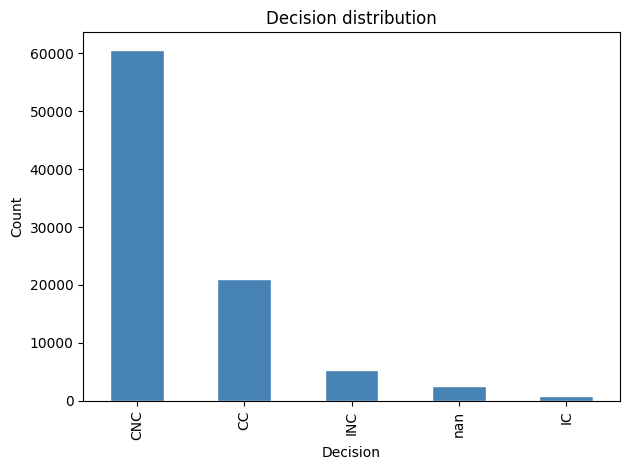

In [24]:
nba_data['decision'].value_counts(dropna=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Decision distribution')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The `decision` column is the core variable of the analysis. It takes four values: CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call). A fifth value — blank (NaN) — indicates plays not detectable without technology.

The distribution shows that CNC dominates with 60,590 entries (67.2% of all rows), followed by CC (21,023), INC (5,391), NaN (2,502), and IC (796). Pelechrinis (2023) notes that CNC criteria changed across seasons — during the 2015 season there were 6.4 CNC entries per game, while during the 2022 season there were almost 14 [PelechrinisL2M]. This inconsistency makes CNC unsuitable for longitudinal analysis. NaN entries are also excluded as they represent plays not detectable without technology. The working dataset therefore consists of CC (21,023), IC (796), and INC (5,391) — a total of 27,210 rows.

- **Season column** — we check the distribution of rows by season to confirm coverage and identify any gaps.

We count the number of rows per season to confirm coverage and identify gaps.

In [25]:
# Games per season
print(nba_data.groupby('season')['gid'].nunique())

season
2015    139
2016    439
2017    428
2018    475
2019    455
2020    395
2021    406
2022    442
2023    474
2024    411
2025    423
Name: gid, dtype: int64


2018 has more games (475) than 2019 (455), yet 2019 has more rows. This means the difference is not in the number of games — we check average actions per game to find the cause.

**Note** — the dataset contains 395–475 games per season, not 1,230. L2M reports are released only for close games (≤5 points in the last two minutes), which represents approximately 35–40% of all regular season games. A standard NBA season has 1,230 games (30 teams × 82 games / 2) [AtlhawksfanaticL2M].

In [26]:
# Rows per game by season
print(nba_data.groupby('season').apply(
    lambda x: len(x) / x['gid'].nunique(), include_groups=False
).round(1))

season
2015    14.2
2016    15.6
2017    17.6
2018    22.3
2019    25.1
2020    20.8
2021    19.5
2022    20.0
2023    24.3
2024    20.1
2025    16.9
dtype: float64


2019 peaks at 25.1 actions per game — the highest in the dataset. This confirms that 2019 has more rows than 2018 despite fewer games because referees reviewed more actions per game. The drop in 2020–2022 reflects both fewer games (395–406 vs 455–475) and fewer actions per game (19.5–20.8 vs 25.1).

**Note** — A standard NBA season has 1,230 games (30 teams × 82 games / 2) [FansidedNBA]

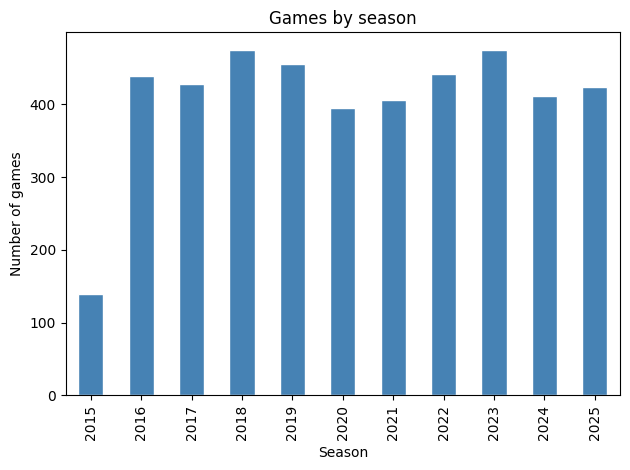

In [27]:
nba_data.groupby('season')['gid'].nunique().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Games by season')
plt.xlabel('Season')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

> **Observation** — 2015 has significantly fewer rows (1,972) and fewer games (139) as it was the first year of L2M reporting. Coverage stabilizes from 2016 onward. The drop in 2020–2022 reflects both fewer games (395–442 vs 455–475 in 2018–2019) and fewer graded actions per game (19.5–20.8 vs 25.1 in 2019). 2025 shows the lowest actions per game (16.9) because the season was still ongoing when the data was collected.

- **Playoff column** — We check the split between regular season and playoff games.

In [28]:
games = nba_data.drop_duplicates(subset='gid')

print('Unique values:')
print(games['playoff'].unique())
print()
print('Missing:', games['playoff'].isnull().sum())
print()
print(games['playoff'].value_counts())
print(f'Total games: {len(games)}')

Unique values:
[False  True]

Missing: 0

playoff
False    4191
True      296
Name: count, dtype: int64
Total games: 4487


> **Observation** — The `playoff` column is a boolean variable with no missing values. At the game level (4,487 unique games), 4,191 games (93.4%) are regular season and 296 games (6.6%) are playoff games. The column is used for period segmentation in RQ1 and will be converted to integer (0/1) if required by specific statistical procedures.

* **Attendance field** `ATTENDANCE` — used as a proxy for crowd pressure. We check the range and distribution of values, including games with zero attendance which correspond to the COVID bubble.

Unique values and missing — we check the range of attendance values and identify missing entries.

In [29]:
print('Unique values:')
print(nba_data['ATTENDANCE'].unique())
print()
print('Missing:', nba_data['ATTENDANCE'].isnull().sum())
print()
print(nba_data['ATTENDANCE'].value_counts(dropna=False))

Unique values:
[18345. 18624. 13109. ... 19734. 19932. 17561.]

Missing: 6509

ATTENDANCE
NaN        6509
18997.0    2345
19800.0    2119
19600.0    1968
19812.0    1752
           ... 
21749.0       4
18434.0       4
14629.0       4
17831.0       2
15393.0       1
Name: count, Length: 2176, dtype: int64


Distribution plot — we visualize the attendance distribution to identify patterns and anomalies.

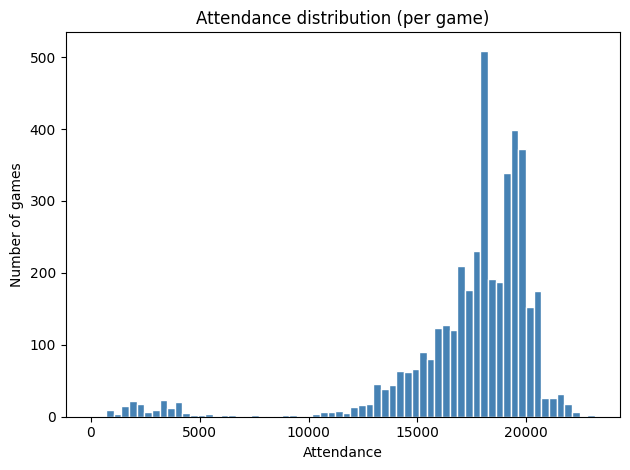

In [30]:
nba_data.drop_duplicates(subset='gid')['ATTENDANCE'].dropna().plot(
    kind='hist', bins='fd', color='steelblue', edgecolor='white')
plt.title('Attendance distribution (per game)')
plt.xlabel('Attendance')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

Low attendance investigation — the histogram shows a small group below 5,000. We identify which seasons these belong to.

In [31]:
print('Rows with ATTENDANCE < 5000:')
print(nba_data[nba_data['ATTENDANCE'] < 5000]['season'].value_counts().sort_index())

Rows with ATTENDANCE < 5000:
season
2021    2864
2022      13
Name: count, dtype: int64


Unexpected finding
— zero attendance appears only in 2022, not in 2020 as expected from the COVID bubble. We investigate which games these are. 2022 low attendance

In [32]:
mask = (nba_data['ATTENDANCE'] < 5000) & (nba_data['season'] == 2022)
cols = ['gid', 'season', 'home_team', 'away_team', 'date', 'call_type', 'decision', 'ATTENDANCE']
print(f'Rows: {mask.sum()}, Unique games: {nba_data[mask]["gid"].nunique()}')
print(nba_data[mask][cols].to_string())

Rows: 13, Unique games: 1
            gid  season home_team away_team        date               call_type decision  ATTENDANCE
59965  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59966  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59967  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59968  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59969  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting       CC         0.0
59970  22100850    2022   Raptors   Nuggets  2022-02-12  Foul: Defense 3 Second      INC         0.0
59971  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59972  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59973  22100850    2022   Raptors   Nuggets  2022-02-12          

We confirm the single 2022 game with restricted attendance and verify that 13 rows correspond to one game.

In [33]:
games = nba_data.drop_duplicates(subset='gid')
print(games.groupby('home_team')['ATTENDANCE'].median().sort_values(ascending=False).head(15))

home_team
Bulls            21116.0
76ers            20319.5
Mavericks        20157.0
Knicks           19812.0
Raptors          19800.0
Heat             19600.0
Nuggets          19520.0
Cavaliers        19432.0
Trail Blazers    19393.0
Clippers         19060.0
Lakers           18997.0
Celtics          18624.0
Spurs            18354.0
Jazz             18306.0
Thunder          18203.0
Name: ATTENDANCE, dtype: float64


Тhe peaks in the attendance distribution reflect fixed arena capacities. Bulls lead with median 21,116, followed by 76ers (20,319) and Mavericks (20,157). This is expected — arenas have a maximum capacity which creates natural clustering. This does not affect our analysis.

In [34]:
def calc_entropy(series):
    counts = pd.cut(series, bins=20).value_counts()
    probs = counts / counts.sum()
    return stats.entropy(probs)

attendance_entropy = nba_data.drop_duplicates(subset='gid').groupby('season')['ATTENDANCE'].apply(
    lambda x: calc_entropy(x.dropna())
)

print(attendance_entropy)

season
2015    2.615408
2016    2.527409
2017    2.599285
2018    2.492446
2019    2.492698
2020    2.613304
2021    2.075035
2022    2.129570
2023    2.453236
2024    2.387664
2025    2.290795
Name: ATTENDANCE, dtype: float64


Pre-COVID seasons (2015–2020) show stable entropy between 2.49 and 2.61, reflecting the natural variation of normal game attendance. The COVID seasons (2021–2022) show a sharp drop to 2.07–2.13, consistent with restricted capacity games clustering around a narrow range of low values. Post-COVID seasons (2023–2025) show partial recovery to 2.29–2.45, but have not returned to Pre-COVID levels. 

The entropy pattern suggests that `ATTENDANCE` may be more appropriately treated as a categorical variable than a continuous one, as it reflects arena capacity constraints and a structural break during the COVID period. This will be considered in the Tidy Data Preparation section.

> **Observation** — The `ATTENDANCE` column records the number of fans present at each game and is used as a proxy for crowd pressure. It has 6,509 missing values (7.2%). The distribution clusters between 13,000–23,000, reflecting fixed arena capacities. Bulls lead with a median of 21,116, followed by 76ers (20,319) and Mavericks (20,157). A secondary cluster of 2,877 rows falls below 5,000 — 2,864 from the 2021 season played with restricted crowd capacity due to the COVID-19 pandemic, and 13 rows from a single Raptors vs Nuggets game (February 12, 2022) played without fans due to local public health restrictions. When analyzing the relationship between attendance and referee bias, the low-attendance group must be treated separately or controlled for via the `season` variable.

* **national_tv**: national TV network for the game, "no" indicates none

In [35]:
print('Unique values (per game):')
print(games['national_tv'].value_counts(dropna=False))
print()
print('Missing:', games['national_tv'].isnull().sum())
print(f'Total games: {len(games)}')

Unique values (per game):
national_tv
no                              3235
ESPN                             358
NBA TV                           355
TNT                              308
ABC                              114
NBATV                             36
TNT/truTV/Max                     32
TNT/truTV                         17
TNT OT                             9
TNT/Max                            6
ABC/ESPN+                          4
ESPN/ESPN2                         3
ABC/ESPN/ESPN+/Disney+             3
ABC/ESPN                           3
ESPN & ABC Simulcast               1
ESPN2                              1
ESPN 2                             1
ABC/ESPN/ESPN2/ESPN+/Disney+       1
Name: count, dtype: int64

Missing: 0
Total games: 4487


> **Observation** — The `national_tv` column identifies the national broadcast network for each game. It is a per-game attribute repeated for every row within a game, so the analysis is performed at the game level (4,487 unique games). There are no missing values. The majority of games were not nationally broadcast (3,235 games, 72.1%). Among nationally broadcast games, ESPN (358), NBA TV (355), and TNT (308) are the most frequent networks, followed by ABC (114). The remaining values represent multi-network simulcasts and variants, which are grouped together with nationally broadcast games for the purposes of analysis. For analysis, `national_tv` is treated as a binary variable: `national` (1) if the game was broadcast on any national network, and `local` (0) if not. This binary grouping captures 1,252 nationally broadcast games (27.9%) versus 3,235 local games (72.1%).

* **Period** — we check which periods are covered.

In [36]:
print('Period distribution:')
print(nba_data['period'].value_counts())

Period distribution:
period
Q4    78374
Q5    10533
Q6     1189
Q7      129
Q8       77
Name: count, dtype: int64


> **Observation** — The `period` column identifies the game period of each graded play. The majority of plays occur in Q4 (78,374, 86.8%). Overtime periods Q5 through Q8 account for 11,928 rows (13.2%), distributed across Q5 (10,533), Q6 (1,189), Q7 (129), and Q8 (77). Overtime games are included in the analysis as they represent close game situations where crowd pressure and referee bias are equally relevant.

##### **Ungrouped Column** 

Several columns are excluded from further analysis. `page` and `file` are PDF pipeline artifacts absent for all API-sourced games. `gcode` and `networks` duplicate information already captured by `gid` and `national_tv` respectively. The remaining 16 API-sourced columns (`PCTime`, `posID`, `posStart`, `posEnd`, `posTeamId`, `teamIdInFavor`, `errorInFavor`, `imgChart`, `GameId`, `GameDate`, `HomeTeamId`, `AwayTeamId`, `L2M_Comments`, `ImposibleIndicator`, `Difficulty`, `VideolLink`, `Qualifier`) have 32,032 or more missing values and are not used in the analysis.

In [37]:
print("PDF artifacts:")
print(nba_data[['file', 'game_details', 'gcode']].head(3))

print("\nDuplicate columns:")
print(nba_data[['national_tv', 'networks']].head(3))

print("\nAPI columns sample:")
print(nba_data[['PCTime', 'ImposibleIndicator', 'Difficulty', 'posID', 'L2M_Comments']].head(3))

# 1. page and file are PDF pipeline artifacts
print("page and file missing (API-sourced games have no PDF):")
print(f"page missing: {nba_data['page'].isna().sum()} / {len(nba_data)}")
print(f"file missing: {nba_data['file'].isna().sum()} / {len(nba_data)}")

# 2. gcode duplicates gid
print("\ngcode vs gid - are they equivalent?")
gcode_decoded = nba_data['gcode'].str.extract(r'(\d+)/(\w+)(\w{3})$')
print(nba_data[['gid', 'gcode']].drop_duplicates('gid').head(5))

# 3. networks duplicates national_tv
print("\nnetworks vs national_tv match rate:")
match = (nba_data['national_tv'] == nba_data['networks']).sum()
total = nba_data['networks'].notna().sum()
print(f"Matching: {match} / {total} ({match/total*100:.1f}%)")

# 4. API columns missing values
api_cols = ['PCTime', 'posID', 'posStart', 'posEnd', 'posTeamId',
            'teamIdInFavor', 'errorInFavor', 'imgChart', 'GameId',
            'GameDate', 'HomeTeamId', 'AwayTeamId', 'L2M_Comments',
            'ImposibleIndicator', 'Difficulty', 'VideolLink', 'Qualifier']
print("\nAPI columns missing values:")
print(nba_data[api_cols].isna().sum())

PDF artifacts:
                     file                        game_details            gcode
0  L2M-CLE-HOU-3-1-15.pdf  Cavaliers @ Rockets (Mar 01, 2015)  20150301/CLEHOU
1  L2M-CLE-HOU-3-1-15.pdf  Cavaliers @ Rockets (Mar 01, 2015)  20150301/CLEHOU
2  L2M-CLE-HOU-3-1-15.pdf  Cavaliers @ Rockets (Mar 01, 2015)  20150301/CLEHOU

Duplicate columns:
  national_tv networks
0       NBATV    NBATV
1       NBATV    NBATV
2       NBATV    NBATV

API columns sample:
  PCTime  ImposibleIndicator Difficulty  posID L2M_Comments
0    NaN                 NaN        NaN    NaN          NaN
1    NaN                 NaN        NaN    NaN          NaN
2    NaN                 NaN        NaN    NaN          NaN
page and file missing (API-sourced games have no PDF):
page missing: 58270 / 90302
file missing: 0 / 90302

gcode vs gid - are they equivalent?
         gid            gcode
0   21400883  20150301/CLEHOU
21  21400880  20150301/GSWBOS
30  21400884  20150301/NOPDEN
43  21400886  20150302/GSWBKN
51

##### NBA L2M Summary

Based on the column-level analysis, the following columns are selected for the analytical dataset: `decision`, `committing_side`, `disadvantaged_side`, and `call_type` for bias measurement and Monte Carlo simulation; `gid`, `date`, `season`, and `playoff` for game identification and temporal segmentation; `home` and `away` for ELO merge; `home_team` and `away_team` for Basketball Reference merge; `ATTENDANCE` and `national_tv` for crowd pressure analysis; `home_score` and `away_score` for in-game context. All other columns are excluded as redundant, structurally incomplete, or not relevant to the research questions.

#### 4.1.2 NBA ELO Ratings

##### Dataset Overview

The secondary dataset contains pre-game ELO ratings for NBA teams, maintained by Neil Paine [NeilPaineELO]. ELO ratings are a measure of team strength based on game outcomes — a team's rating increases after a win and decreases after a loss, with the magnitude depending on the opponent's rating. The dataset covers all NBA games from 1946 to 2025, providing a continuous measure of relative team strength at the time of each game. For this study, only seasons from 2015 to 2025 are used, matching the coverage of the L2M dataset. The ELO rating difference between the home and away team at the time of each game is used as a proxy for pre-game team strength in RQ2. Archive of NBA Elo data (updated from FiveThirtyEight version) can be found at https://fivethirtyeight.com/features/how-we-calculate-nba-elo-ratings/

In [42]:
elo_data = pd.read_csv('data/input/nba_elo.zip', low_memory=False)
# Shape
print('Shape:', elo_data.shape)

Shape: (151410, 15)


The dataset contains 151,410 rows and 15 columns. Each row represents a single NBA game with pre-game ELO ratings for both the home and away team. The dataset is fully described in the source repository [NeilPaineELO]. Based on the source documentation, the following columns are identified as candidates for analysis.

##### Data Quality

**Data types** — we inspect the type of each column to identify parsing issues. 

In [43]:
print(elo_data.head())
print(elo_data.dtypes)

         date  season  neutral playoff team1 team2  elo1_pre   elo2_pre  \
0  1946-11-01    1947        0     NaN   TRH   NYK    1300.0  1300.0000   
1  1946-11-01    1947        0     NaN   NYK   TRH    1300.0  1300.0000   
2  1946-11-02    1947        0     NaN   PRO   BOS    1300.0  1300.0000   
3  1946-11-02    1947        0     NaN   STB   PIT    1300.0  1300.0000   
4  1946-11-02    1947        0     NaN   CHS   NYK    1300.0  1306.7233   

   elo_prob1  elo_prob2  elo1_post  elo2_post  score1  score2  is_home  
0   0.640065   0.359935  1293.2767  1306.7233      66      68        1  
1   0.359935   0.640065  1306.7233  1293.2767      68      66        0  
2   0.640065   0.359935  1305.1542  1294.8458      59      53        1  
3   0.640065   0.359935  1304.6908  1295.3092      56      51        1  
4   0.631101   0.368899  1309.6521  1297.0712      63      47        1  
date          object
season         int64
neutral        int64
playoff       object
team1         object
team2 

> All 15 columns are inspected for parsing issues. `date` is stored as object and requires datetime conversion before merging with the L2M dataset. `playoff` is stored as object — inspection is required to determine its values. All numeric columns (`elo1_pre`, `elo2_pre`, `elo_prob1`, `elo_prob2`, `elo1_post`, `elo2_post`, `score1`, `score2`, `season`, `neutral`, `is_home`) have the expected types. Conversions will be performed in the Tidy Data Preparation section.

**Missing Values**

In [44]:
# Missing values
print('\nMissing values:')
print(elo_data.isnull().sum()[elo_data.isnull().sum() > 0])


Missing values:
playoff    141844
dtype: int64


> Only one column has missing values: `playoff` has 141,844 missing values out of 151,410 rows (93.7%). This reflects that the vast majority of NBA games are regular season games. Non-missing values indicate playoff games. Missing values in `playoff` will be treated as regular season (0) in the Tidy Data Preparation section.

**Duplicate Values**

In [45]:
print('Duplicate rows:', elo_data.duplicated().sum())

Duplicate rows: 0


> The dataset contains no duplicate rows.

##### Column-Level Analysis

In [46]:
print(sorted(elo_data.columns.tolist(), key=str.lower))

['date', 'elo1_post', 'elo1_pre', 'elo2_post', 'elo2_pre', 'elo_prob1', 'elo_prob2', 'is_home', 'neutral', 'playoff', 'score1', 'score2', 'season', 'team1', 'team2']


In [47]:
print("Game identifiers:")
print(elo_data[['date', 'season', 'playoff', 'neutral']].drop_duplicates('date').head(5))

print("\nTeam columns:")
print(elo_data[['team1', 'team2']].head(5))

print("\nPre-game ELO:")
print(elo_data[['elo1_pre', 'elo2_pre', 'elo_prob1', 'elo_prob2']].head(5))

print("\nPost-game ELO:")
print(elo_data[['elo1_post', 'elo2_post']].head(5))

print("\nScore:")
print(elo_data[['score1', 'score2']].head(5))

print("\nOther:")
print(elo_data[['is_home']].head(5))

Game identifiers:
          date  season playoff  neutral
0   1946-11-01    1947     NaN        0
2   1946-11-02    1947     NaN        0
10  1946-11-03    1947     NaN        0
12  1946-11-04    1947     NaN        0
14  1946-11-05    1947     NaN        0

Team columns:
  team1 team2
0   TRH   NYK
1   NYK   TRH
2   PRO   BOS
3   STB   PIT
4   CHS   NYK

Pre-game ELO:
   elo1_pre   elo2_pre  elo_prob1  elo_prob2
0    1300.0  1300.0000   0.640065   0.359935
1    1300.0  1300.0000   0.359935   0.640065
2    1300.0  1300.0000   0.640065   0.359935
3    1300.0  1300.0000   0.640065   0.359935
4    1300.0  1306.7233   0.631101   0.368899

Post-game ELO:
   elo1_post  elo2_post
0  1293.2767  1306.7233
1  1306.7233  1293.2767
2  1305.1542  1294.8458
3  1304.6908  1295.3092
4  1309.6521  1297.0712

Score:
   score1  score2
0      66      68
1      68      66
2      59      53
3      56      51
4      63      47

Other:
   is_home
0        1
1        0
2        1
3        1
4        1


The dataset contains 15 columns organised into five groups.

**Game identifiers** — `date`, `season`, `playoff`, `neutral`. `date` is in ISO format (YYYY-MM-DD) and is used as the merge key with the L2M dataset. `season` identifies the NBA season. `playoff` is NaN for regular season games and contains a round identifier for playoff games. `neutral` is binary (0/1) indicating neutral venue games.

**Team columns** — `team1` and `team2` use three-letter abbreviations consistent with the L2M `home` and `away` columns

In [48]:
# Unique team abbreviations in ELO (2015-2025 only)
elo_recent = elo_data[elo_data['season'] >= 2015]
elo_teams = set(elo_recent['team1'].unique()) | set(elo_recent['team2'].unique())
l2m_teams = set(nba_data['home'].unique()) | set(nba_data['away'].unique())

print("In ELO but not in L2M:")
print(elo_teams - l2m_teams)

print("\nIn L2M but not in ELO:")
print(l2m_teams - elo_teams)

In ELO but not in L2M:
{'BRK', 'CHO', 'PHO'}

In L2M but not in ELO:
{'CHA', 'PHX', 'BKN'}


Comparison with the L2M `home` and `away` columns confirms three mismatches  BKN<->BRK, PHX<->PHO, CHA<->CHO. These will be remapped in the Tidy Data Preparation section before merging.

**Pre-game ELO** — `elo1_pre` and `elo2_pre` are the ELO ratings for `team1` and `team2` before the game. `elo_prob1` and `elo_prob2` are the derived win probabilities. The ELO difference (`elo1_pre - elo2_pre`) is used as the measure of pre-game team strength in RQ2.

**Post-game ELO** — `elo1_post` and `elo2_post` are the updated ratings after the game. Not used in the analysis.

**Score** — `score1` and `score2` are the final scores. Not used in the analysis.

**Other** — `is_home` indicates whether `team1` is the home team (1) or away team (0). Used to verify merge correctness.

##### NBA ELO Summary

The ELO dataset contains 151,410 rows and 15 columns covering all NBA seasons from 1947 to 2025. For this study, only seasons 2015–2025 are retained. The following columns are selected for the analytical dataset: `date` and `season` for merging with the L2M dataset, `team1` and `team2` for team identification, `elo1_pre` and `elo2_pre` for pre-game strength measurement, and `playoff` for season type verification. Three team abbreviation mismatches (`BKN`→`BRK`, `CHA`→`CHO`, `PHX`→`PHO`) will be resolved in the Tidy Data Preparation section. All other columns are excluded as not relevant to the research questions.

#### 4.1.3 Basketball Reference Team Stats

##### Dataset Overview #####

The tertiary dataset contains season-level team statistics from Basketball Reference [BRef], manually downloaded for each season from 2014–15 to 2024–25. 

In [66]:
files = [f for f in os.listdir('data/input/basketball-reference/') if f.endswith('.csv')]
print(sorted(files))

['sportsref_download-2014-15.csv', 'sportsref_download-2015-16.csv', 'sportsref_download-2016-17.csv', 'sportsref_download-2017-18.csv', 'sportsref_download-2018-19.csv', 'sportsref_download-2019-20.csv', 'sportsref_download-2020-21.csv', 'sportsref_download-2021-22.csv', 'sportsref_download-2022-23.csv', 'sportsref_download-2023-24.csv', 'sportsref_download-2024-25.csv']


In [69]:
dfs = []
for f in sorted(files):
    season_str = f.split('sportsref_download-')[1].replace('.csv', '')
    season_int = seasons[season_str]
    df = pd.read_csv(f'data/input/basketball-reference/{f}')
    df['season'] = season_int
    dfs.append(df)
bref_data = pd.concat(dfs, ignore_index=True)
print('Shape:', bref_data.shape)
print(bref_data.head())



Shape: (330, 29)
    Rk                    Team   Age     W     L  PW  PL    MOV   SOS    SRS  \
0  1.0  Golden State Warriors*  26.6  67.0  15.0  65  17  10.10 -0.09  10.01   
1  2.0   Los Angeles Clippers*  28.8  56.0  26.0  58  24   6.59  0.22   6.80   
2  3.0      San Antonio Spurs*  29.8  55.0  27.0  58  24   6.20  0.14   6.34   
3  4.0          Atlanta Hawks*  27.8  60.0  22.0  56  26   5.43 -0.68   4.75   
4  5.0    Cleveland Cavaliers*  26.9  53.0  29.0  53  29   4.48 -0.40   4.08   

   ...  Offense Four Factors_ORB%  Offense Four Factors_FT/FGA  \
0  ...                       24.1                        0.184   
1  ...                       22.8                        0.215   
2  ...                       23.4                        0.200   
3  ...                       21.4                        0.201   
4  ...                       26.8                        0.216   

   Defense Four Factors_eFG%  Defense Four Factors_TOV%  \
0                      0.470                  

The dataset contains 330 rows (30 teams × 11 seasons) and 29 columns covering offensive and defensive performance metrics, attendance, and arena information. For this study, only `Team`, `SRS`, `Attend./G`, and `season` are used. `SRS` (Simple Rating System) measures overall team strength adjusted for strength of schedule. `Attend./G` measures average home attendance per game and serves as the crowd pressure proxy in RQ3. 

**Dataset Overview**

In [70]:
print(bref_data.dtypes)

Rk                             float64
Team                            object
Age                            float64
W                              float64
L                              float64
PW                               int64
PL                               int64
MOV                            float64
SOS                            float64
SRS                            float64
ORtg                           float64
DRtg                           float64
NRtg                           float64
Pace                           float64
FTr                            float64
3PAr                           float64
TS%                            float64
Offense Four Factors_eFG%      float64
Offense Four Factors_TOV%      float64
Offense Four Factors_ORB%      float64
Offense Four Factors_FT/FGA    float64
Defense Four Factors_eFG%      float64
Defense Four Factors_TOV%      float64
Defense Four Factors_DRB%      float64
Defense Four Factors_FT/FGA    float64
Arena                    

All 29 columns are inspected for parsing issues. `Team` and `Arena` are stored as object (string) as expected. All numeric columns are float64 or int64. `season` is int64. No parsing issues are identified — all columns have the expected types. No conversions are required before analysis.

**Missing Values**

In [71]:
print('Missing values:')
print(bref_data.isnull().sum()[bref_data.isnull().sum() > 0])

Missing values:
Attend.      4
Attend./G    4
dtype: int64


In [72]:
print(bref_data[bref_data['Attend./G'].isnull()][['Team', 'season', 'Arena', 'Attend.', 'Attend./G']])

                      Team  season                    Arena  Attend.  \
195            Miami Heat*    2021   AmericanAirlines Arena      NaN   
196         Indiana Pacers    2021  Bankers Life Fieldhouse      NaN   
203       Sacramento Kings    2021          Golden 1 Center      NaN   
209  Oklahoma City Thunder    2021  Chesapeake Energy Arena      NaN   

     Attend./G  
195        NaN  
196        NaN  
203        NaN  
209        NaN  


Only `Attend.` and `Attend./G` have missing values — 4 rows each, all from the 2021 season. These correspond to teams that played without fans due to COVID-19 restrictions. Since `Attend./G` is the crowd pressure proxy in RQ3, these 4 rows will be excluded from the attendance analysis in the Tidy Data Preparation section.

**Duplicate Values**

In [74]:
print('Duplicate rows:', bref_data.duplicated().sum())

Duplicate rows: 0


The dataset contains no duplicate rows.

##### Column-Level Analysis

In [75]:
print(sorted(bref_data.columns.tolist(), key=str.lower))

['3PAr', 'Age', 'Arena', 'Attend.', 'Attend./G', 'Defense Four Factors_DRB%', 'Defense Four Factors_eFG%', 'Defense Four Factors_FT/FGA', 'Defense Four Factors_TOV%', 'DRtg', 'FTr', 'L', 'MOV', 'NRtg', 'Offense Four Factors_eFG%', 'Offense Four Factors_FT/FGA', 'Offense Four Factors_ORB%', 'Offense Four Factors_TOV%', 'ORtg', 'Pace', 'PL', 'PW', 'Rk', 'season', 'SOS', 'SRS', 'Team', 'TS%', 'W']


The dataset contains 29 columns organized into five groups.

**Team identifiers** — `Team`, `Rk`, `season`. `Team` is the primary merge key with the L2M dataset. `Rk` is the season ranking by SRS and is not used in the analysis. `season` identifies the NBA season.

**Performance metrics** — `W`, `L`, `PW`, `PL`, `MOV`, `SOS`, `SRS`, `ORtg`, `DRtg`, `NRtg`, `Pace`, `FTr`, `3PAr`, `TS%`, `Age`. `SRS` (Simple Rating System) is the only performance metric used in the analysis as a season-level measure of team strength. All other performance metrics are not used.

**Offense Four Factors** — `Offense Four Factors_eFG%`, `Offense Four Factors_TOV%`, `Offense Four Factors_ORB%`, `Offense Four Factors_FT/FGA`. Advanced offensive metrics not used in the analysis.

**Defense Four Factors** — `Defense Four Factors_eFG%`, `Defense Four Factors_TOV%`, `Defense Four Factors_DRB%`, `Defense Four Factors_FT/FGA`. Advanced defensive metrics not used in the analysis.

**Attendance** — `Arena`, `Attend.`, `Attend./G`. `Attend./G` is the average home attendance per game and serves as the crowd pressure proxy in RQ3. `Attend.` is the total season attendance and is not used. `Arena` identifies the home arena and is not used in the analysis.

In [76]:
# Check Team name format in bref vs home_team in L2M
bref_teams = set(bref_data['Team'].str.replace('*', '', regex=False).unique())
l2m_teams = set(nba_data['home_team'].unique())

print("In BRef but not in L2M:")
print(bref_teams - l2m_teams)

print("\nIn L2M but not in BRef:")
print(l2m_teams - bref_teams)

In BRef but not in L2M:
{'Golden State Warriors', 'Dallas Mavericks', 'Chicago Bulls', 'New York Knicks', 'Minnesota Timberwolves', 'Philadelphia 76ers', 'Utah Jazz', 'Charlotte Hornets', 'Toronto Raptors', 'Detroit Pistons', 'Memphis Grizzlies', 'Miami Heat', 'Boston Celtics', 'Atlanta Hawks', 'San Antonio Spurs', 'Brooklyn Nets', 'Phoenix Suns', 'New Orleans Pelicans', 'Orlando Magic', 'Oklahoma City Thunder', 'Milwaukee Bucks', 'Houston Rockets', 'Indiana Pacers', 'Cleveland Cavaliers', 'Los Angeles Lakers', 'Los Angeles Clippers', 'Denver Nuggets', 'Washington Wizards', 'Sacramento Kings', 'Portland Trail Blazers'}

In L2M but not in BRef:
{'Hornets', 'Heat', 'Pistons', 'Nets', 'Lakers', 'Celtics', 'Raptors', 'Trail Blazers', 'Timberwolves', 'Suns', 'Magic', 'Grizzlies', 'Pacers', 'Kings', 'Pelicans', 'Rockets', 'Thunder', 'Clippers', 'Cavaliers', 'Bulls', '76ers', 'Nuggets', 'Spurs', 'Warriors', 'Wizards', 'Hawks', 'Bucks', 'Jazz', 'Knicks', 'Mavericks'}


In [77]:
# Verify - BRef full names vs L2M nicknames
print(bref_data['Team'].str.replace('*', '', regex=False).head(5).values)
print(nba_data['home_team'].head(5).values)

['Golden State Warriors' 'Los Angeles Clippers' 'San Antonio Spurs'
 'Atlanta Hawks' 'Cleveland Cavaliers']
['Rockets' 'Rockets' 'Rockets' 'Rockets' 'Rockets']


> `Team` in the Basketball Reference dataset uses full team names (e.g., `Golden State Warriors`), while `home_team` and `away_team` in the L2M dataset use nicknames only (e.g., `Warriors`). A full name to nickname mapping will be applied in the Tidy Data Preparation section before merging.

In [80]:
# Check if L2M nickname is contained in BRef Team name
l2m_teams = set(nba_data['home_team'].unique())

mapping = {}
for team in bref_data['Team'].str.replace('*', '', regex=False).unique():
    for nickname in l2m_teams:
        if nickname in team:
            mapping[team] = nickname

print(pd.DataFrame(list(mapping.items()), columns=['BRef_Team', 'L2M_nickname']).sort_values('L2M_nickname'))
print(f"\nMapped: {len(mapping)} / {bref_data['Team'].str.replace('*', '', regex=False).nunique()}")

                 BRef_Team   L2M_nickname
28      Philadelphia 76ers          76ers
14         Milwaukee Bucks          Bucks
9            Chicago Bulls          Bulls
4      Cleveland Cavaliers      Cavaliers
17          Boston Celtics        Celtics
1     Los Angeles Clippers       Clippers
7        Memphis Grizzlies      Grizzlies
3            Atlanta Hawks          Hawks
20              Miami Heat           Heat
22       Charlotte Hornets        Hornets
16               Utah Jazz           Jazz
24        Sacramento Kings          Kings
29         New York Knicks         Knicks
26      Los Angeles Lakers         Lakers
25           Orlando Magic          Magic
10        Dallas Mavericks      Mavericks
21           Brooklyn Nets           Nets
23          Denver Nuggets        Nuggets
15          Indiana Pacers         Pacers
12    New Orleans Pelicans       Pelicans
19         Detroit Pistons        Pistons
8          Toronto Raptors        Raptors
6          Houston Rockets        

> `Team` in the Basketball Reference dataset uses full team names (e.g., `Golden State Warriors`), while `home_team` and `away_team` in the L2M dataset use nicknames (e.g., `Warriors`). A substring match confirms that all 30 NBA team nicknames are contained within their corresponding full names, with no ambiguous matches. The mapping will be applied in the Tidy Data Preparation section before merging.

##### Basketball Reference Team Summary

The Basketball Reference dataset contains 330 rows and 29 columns covering 30 NBA teams across 11 seasons (2015–2025). The following columns are selected for the analytical dataset: `Team` for team identification and merge with the L2M dataset via nickname substring matching, `season` for temporal alignment, `SRS` as a season-level measure of team strength, and `Attend./G` as the crowd pressure proxy in RQ3. Four rows with missing `Attend./G` values correspond to COVID-restricted games in the 2021 season and will be excluded from the attendance analysis. All other columns are not used in the analysis.

In [81]:
print(bref_data[['Team', 'team_nickname', 'season', 'SRS', 'Attend./G']].head(10))

                      Team  team_nickname  season    SRS  Attend./G
0   Golden State Warriors*       Warriors    2015  10.01    19596.0
1    Los Angeles Clippers*       Clippers    2015   6.80    19168.0
2       San Antonio Spurs*          Spurs    2015   6.34    18606.0
3           Atlanta Hawks*          Hawks    2015   4.75    17412.0
4     Cleveland Cavaliers*      Cavaliers    2015   4.08    20562.0
5  Portland Trail Blazers*  Trail Blazers    2015   4.41    19472.0
6         Houston Rockets*        Rockets    2015   3.82    18230.0
7       Memphis Grizzlies*      Grizzlies    2015   3.62    17329.0
8         Toronto Raptors*        Raptors    2015   2.45    19752.0
9           Chicago Bulls*          Bulls    2015   2.54    21625.0


### 4.2 Exploratory Data Analysis (EDA)

## 6. Limitations

Several limitations should be considered when interpreting the results.

The L2M dataset covers only close games — games within 5 points in the last two minutes. This introduces a selection bias: the sample is not representative of all NBA games, and findings may not generalize to non-close games.

The Monte Carlo simulation uses 10,000 runs, which produces stable empirical p-values for moderate effect sizes but may underestimate significance for very large effects (reporting p < 0.001 rather than exact values).

Multiple hypothesis tests are conducted without Bonferroni correction, following Pelechrinis (2023) [PelechrinisL2M], which increases the risk of Type I error inflation.

The COVID period (2021–2022) conflates two potentially distinct conditions — games with zero attendance and games with restricted capacity. These are treated as a single period for simplicity.

SRS from Basketball Reference is a season-level measure and does not capture within-season variation in team strength, unlike the game-level ELO ratings.

Player and referee names were excluded from the dataset on ethical grounds. As a result, player-level bias analysis relies on career-level PER groupings rather than individual identification, which limits the granularity of the findings.

## Reference

[PelechrinisL2M] Pelechrinis, K. (2023). Quantifying implicit biases in refereeing using NBA referees as a testbed. *Scientific Reports*, 13, 4664. https://doi.org/10.1038/s41598-023-31799-y  
[PelechrinisCode] Pelechrinis, K. (2023). NBA-ref-analysis. GitHub. https://github.com/kpelechrinis/NBA-ref-analysis  
[AtlhawksfanaticL2M] atlhawksfanatic. (2025). L2M: NBA Last Two Minute Reports. GitHub. https://github.com/atlhawksfanatic/L2M  
[BRef] Basketball Reference. Team Statistics 2015-2025. https://www.basketball-reference.com (manually downloaded)   
[NeilPaineELO] Paine, N. NBA ELO ratings. https://github.com/Neil-Paine-1/NBA-elo/blob/main/README.md  
[FansidedNBA] FanSided. (2024). How many games are in the NBA season? https://fansided.com/posts/how-many-games-are-in-the-nba-season-01j8kcxt31rr  
[ErikstadJohansen2020] Erikstad, M. K., & Johansen, B. T. (2020). Referee bias in professional football: Favoritism toward successful teams in potential penalty situations. Frontiers in Sports and Active Living, 2, 19. https://doi.org/10.3389/fspor.2020.00019  
[Barrett2021] Barrett, D. (2021). Star player bias in the NBA: A quantile regression approach. Empirical Economics Bulletin, 14(1), 9. 
[Rothman1990] Rothman, K. J. (1990). No adjustments are needed for multiple  comparisons. Epidemiology, 1(1), 43–46. https://doi.org/10.1097/00001648-199001000-00010


